# CS-RMP2 Result comparison 
Results of the implementation compared to those obtained with [Qchem](https://doi.org/10.1080/00268976.2014.952696). Consider that we only have up to 1E-8 information in the energy values. Therefore any error below that is considered (for now) negligible.  

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from py_mods.src.SCF.basis_utils import even_temp_uncontr_str
from py_mods.src.SCF.CSRHF import CS_RHF
from py_mods.src.MP2.CSMP2 import CS_MP2
from py_mods.src.SCF.external import RHF_context_from_pyscf

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

# Definition of basis and intgrals 

In [2]:
He_tempered_str = even_temp_uncontr_str(
    "He", "S", 7.668876968794860e-002, 1.9581497063588078, 21
)  # because this is the reference data

pyscf_args_qz = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": 'aug-cc-pvqz',
}

We generate an example of the context classes we will need for the implementation:

In [3]:
He_1s2_qz_cxt = RHF_context_from_pyscf(**pyscf_args_qz)
He_2s2_qz_cxt = RHF_context_from_pyscf(**pyscf_args_qz)
He_1s2_even_cxt = RHF_context_from_pyscf(
    **pyscf_args_qz, parseable_basis=He_tempered_str
)
He_2s2_even_cxt = RHF_context_from_pyscf(
    **pyscf_args_qz, parseable_basis=He_tempered_str
)

He_2s2_qz_cxt.occupation = np.array([0, 2, 0])
He_2s2_even_cxt.occupation = np.array([0, 2, 0])

And define the parser for Qchem date stored in the data directory:

In [4]:
def load_traj(filename):
    with open(filename) as f:
        cont = f.readlines()
    cont = [line.strip().replace("(", "").replace(")", "") for line in cont]
    thetas = np.array([int(line.split(";")[0]) for line in cont])
    eners = [
        line.split(";")[1].strip().replace(" ", "").replace(",", "+").replace("+-", "-")
        + "j"
        for line in cont
    ]
    eners = np.array([complex(a) for a in eners])

    return thetas, eners

# 1s2 Helium 
## aug-cc-pvqz

In [5]:
thetas_qz_1s2, E_MP2_qz_1s2_qchem = load_traj("data/He_1s2_augqz_mp2_qchem.dat")

In [6]:
E_mp2_qz_1s2_impl = []
for i, theta in enumerate(thetas_qz_1s2):
    print(f'Calculating traj theta = {theta/1000} ({i+1} / {len(thetas_qz_1s2)})')
    He_1s2_qz_cxt = RHF_context_from_pyscf(**pyscf_args_qz)
    He_1s2_qz_cxt.theta = theta/1000

    He_1s2_qz_res = CS_RHF(He_1s2_qz_cxt)

    He_1s2_qz_mp2 = CS_MP2(He_1s2_qz_res)
    E_mp2_qz_1s2_impl.append(He_1s2_qz_mp2.E_MP2)


E_mp2_qz_1s2_impl = np.array(E_mp2_qz_1s2_impl)

Calculating traj theta = 0.0 (1 / 9)
Calculating traj theta = 0.01 (2 / 9)
Calculating traj theta = 0.02 (3 / 9)
Calculating traj theta = 0.03 (4 / 9)
Calculating traj theta = 0.04 (5 / 9)
Calculating traj theta = 0.05 (6 / 9)
Calculating traj theta = 0.06 (7 / 9)
Calculating traj theta = 0.07 (8 / 9)
Calculating traj theta = 0.08 (9 / 9)


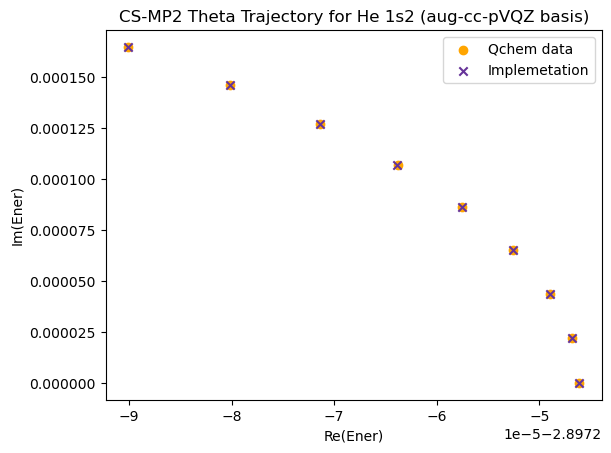

In [7]:
plt.scatter(E_MP2_qz_1s2_qchem.real, E_MP2_qz_1s2_qchem.imag, label="Qchem data", marker="o", c="orange")
plt.scatter(
    E_mp2_qz_1s2_impl.real,
    E_mp2_qz_1s2_impl.imag,
    label="Implemetation",
    c="RebeccaPurple",
    marker="x",
)
plt.title("CS-MP2 Theta Trajectory for He 1s2 (aug-cc-pVQZ basis)")
plt.legend()
plt.xlabel("Re(Ener)")
plt.ylabel("Im(Ener)")
plt.show()

In [8]:
error = E_MP2_qz_1s2_qchem - E_mp2_qz_1s2_impl
print(f"Mean error: {np.mean(error): 6.4E}")
print(f"Max error:  {np.max(error): 6.4E}")

Mean error: -6.3032E-10-2.5080E-11j
Max error:   4.3893E-09+1.7276E-09j


## Even tempered basis

In [9]:
thetas_even_1s2, E_MP2_even_1s2_qchem = load_traj("data/He_1s2_eventemp_mp2_qchem.dat")

In [10]:
E_mp2_even_1s2_impl = []
for i, theta in enumerate(thetas_even_1s2):
    print(f'Calculating traj theta = {theta/1000} ({i+1} / {len(thetas_even_1s2)})')
    He_1s2_even_cxt = RHF_context_from_pyscf(
        **pyscf_args_qz, parseable_basis=He_tempered_str
    )

    He_1s2_even_cxt.theta = theta/1000

    He_1s2_even_res = CS_RHF(He_1s2_even_cxt)

    He_1s2_even_mp2 = CS_MP2(He_1s2_even_res)
    E_mp2_even_1s2_impl.append(He_1s2_even_mp2.E_MP2)


E_mp2_even_1s2_impl = np.array(E_mp2_even_1s2_impl)

Calculating traj theta = 0.0 (1 / 9)
Calculating traj theta = 0.01 (2 / 9)
Calculating traj theta = 0.02 (3 / 9)
Calculating traj theta = 0.03 (4 / 9)
Calculating traj theta = 0.04 (5 / 9)
Calculating traj theta = 0.05 (6 / 9)
Calculating traj theta = 0.06 (7 / 9)
Calculating traj theta = 0.07 (8 / 9)
Calculating traj theta = 0.08 (9 / 9)


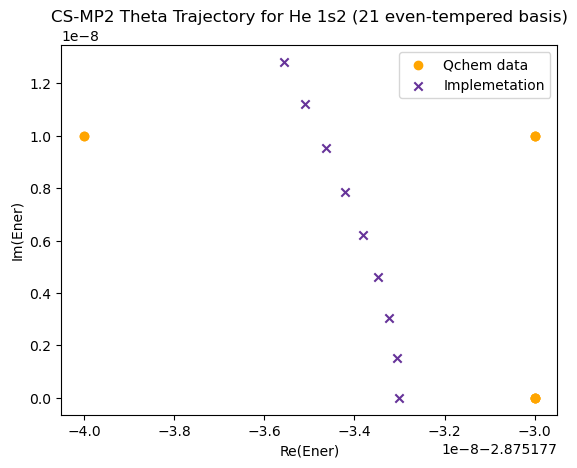

In [11]:
plt.scatter(E_MP2_even_1s2_qchem.real, E_MP2_even_1s2_qchem.imag, label="Qchem data", marker="o", c="orange")
plt.scatter(
    E_mp2_even_1s2_impl.real,
    E_mp2_even_1s2_impl.imag,
    label="Implemetation",
    c="RebeccaPurple",
    marker="x",
)
plt.title("CS-MP2 Theta Trajectory for He 1s2 (21 even-tempered basis)")
plt.legend()
plt.xlabel("Re(Ener)")
plt.ylabel("Im(Ener)")
plt.show()

In [12]:
error = E_MP2_even_1s2_qchem - E_mp2_even_1s2_impl
print(f"Mean error: {np.mean(error): 6.4E}")
print(f"Max error:  {np.max(error): 6.4E}")

Mean error:  1.7897E-09-7.6194E-10j
Max error:   4.6417E-09+4.6575E-10j


# 2s2
## auc-cc-pvqz

In [13]:
thetas_qz_2s2, E_MP2_qz_2s2_qchem = load_traj('data/He_2s2_augqz_mp2_qchem.dat')

In [14]:
E_mp2_qz_2s2_impl = []
for i, theta in enumerate(thetas_qz_2s2):
    print(f'Calculating traj theta = {theta/1000} ({i+1} / {len(thetas_qz_2s2)})')
    He_2s2_qz_cxt = RHF_context_from_pyscf(**pyscf_args_qz)
    He_2s2_qz_cxt.theta = theta/1000
    He_2s2_qz_cxt.occupation = np.array([0, 2, 0])

    He_2s2_qz_res = CS_RHF(He_2s2_qz_cxt)

    He_2s2_qz_mp2 = CS_MP2(He_2s2_qz_res)
    E_mp2_qz_2s2_impl.append(He_2s2_qz_mp2.E_MP2)


E_mp2_qz_2s2_impl = np.array(E_mp2_qz_2s2_impl)

Calculating traj theta = 0.0 (1 / 9)
Calculating traj theta = 0.01 (2 / 9)
Calculating traj theta = 0.02 (3 / 9)
Calculating traj theta = 0.03 (4 / 9)
Calculating traj theta = 0.04 (5 / 9)
Calculating traj theta = 0.05 (6 / 9)
Calculating traj theta = 0.06 (7 / 9)
Calculating traj theta = 0.07 (8 / 9)
Calculating traj theta = 0.08 (9 / 9)


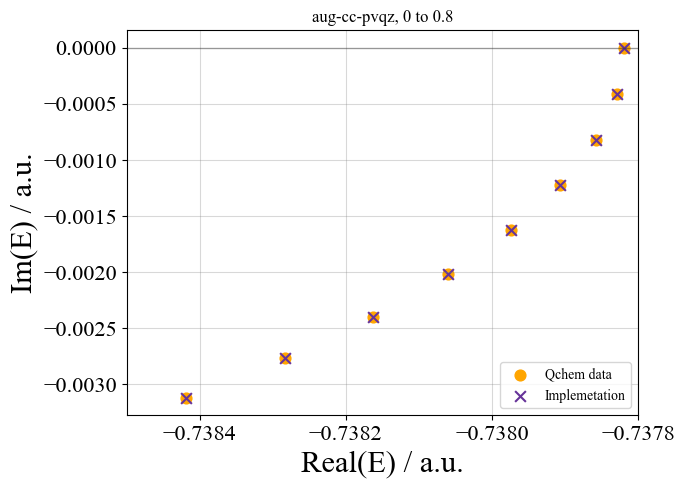

In [50]:
fig, ax = plt.subplots(figsize=(6.6, 5))

ss=60

ax.scatter(E_MP2_qz_2s2_qchem.real, E_MP2_qz_2s2_qchem.imag, label="Qchem data", marker="o", c="orange", s=ss)
ax.scatter(
    E_mp2_qz_2s2_impl.real,
    E_mp2_qz_2s2_impl.imag,
    label="Implemetation",
    c="RebeccaPurple",
    marker="x",
    s=ss
)

ax.axhline(0, color='black', linewidth=1, alpha=0.3)
ax.axvline(0, color='black', linewidth=1, alpha=0.3)

# ax.spines[['top', 'right']].set_visible(False)

ax.set_xlabel('Real(E) / a.u.', fontsize=22)
ax.set_ylabel('Im(E) / a.u.', fontsize=22)
ax.tick_params(axis='both', labelsize=16)

ax.grid(True, which='major', color='gray', linestyle='-', alpha=0.3, zorder=0)

plt.xlim([-.73850,-.7378])
# plt.ylim([-3, 0.2])

plt.title("aug-cc-pvqz, 0 to 0.8")
ax.legend()
plt.show()

In [16]:
error = E_MP2_qz_2s2_qchem - E_mp2_qz_2s2_impl
print(f"Mean error: {np.mean(error): 6.4E}")
print(f"Max error:  {np.max(error): 6.4E}")

Mean error:  4.3564E-10+1.0314E-09j
Max error:   4.6613E-09+4.2150E-10j


## Even tempered 

In [17]:
thetas_even_2s2, E_MP2_even_2s2_qchem = load_traj("data/He_2s2_eventemp_mp2_qchem.dat")

In [18]:
E_mp2_even_2s2_impl = []
for i, theta in enumerate(thetas_even_2s2):
    print(f'Calculating traj theta = {theta/1000} ({i+1} / {len(thetas_even_2s2)})')
    He_2s2_even_cxt = RHF_context_from_pyscf(
        **pyscf_args_qz, parseable_basis=He_tempered_str
    )

    He_2s2_even_cxt.theta = theta/1000
    He_2s2_even_cxt.occupation = np.array([0, 2, 0])

    He_2s2_even_res = CS_RHF(He_2s2_even_cxt)

    He_2s2_even_mp2 = CS_MP2(He_2s2_even_res)
    E_mp2_even_2s2_impl.append(He_2s2_even_mp2.E_MP2)


E_mp2_even_2s2_impl = np.array(E_mp2_even_2s2_impl)

Calculating traj theta = 0.0 (1 / 41)
Calculating traj theta = 0.01 (2 / 41)
Calculating traj theta = 0.02 (3 / 41)
Calculating traj theta = 0.03 (4 / 41)
Calculating traj theta = 0.04 (5 / 41)
Calculating traj theta = 0.05 (6 / 41)
Calculating traj theta = 0.06 (7 / 41)
Calculating traj theta = 0.07 (8 / 41)
Calculating traj theta = 0.08 (9 / 41)
Calculating traj theta = 0.09 (10 / 41)
Calculating traj theta = 0.1 (11 / 41)
Calculating traj theta = 0.11 (12 / 41)
Calculating traj theta = 0.12 (13 / 41)
Calculating traj theta = 0.13 (14 / 41)
Calculating traj theta = 0.14 (15 / 41)
Calculating traj theta = 0.15 (16 / 41)
Calculating traj theta = 0.16 (17 / 41)
Calculating traj theta = 0.17 (18 / 41)
Calculating traj theta = 0.18 (19 / 41)
Calculating traj theta = 0.19 (20 / 41)
Calculating traj theta = 0.2 (21 / 41)
Calculating traj theta = 0.21 (22 / 41)
Calculating traj theta = 0.22 (23 / 41)
Calculating traj theta = 0.23 (24 / 41)
Calculating traj theta = 0.24 (25 / 41)
Calculating 

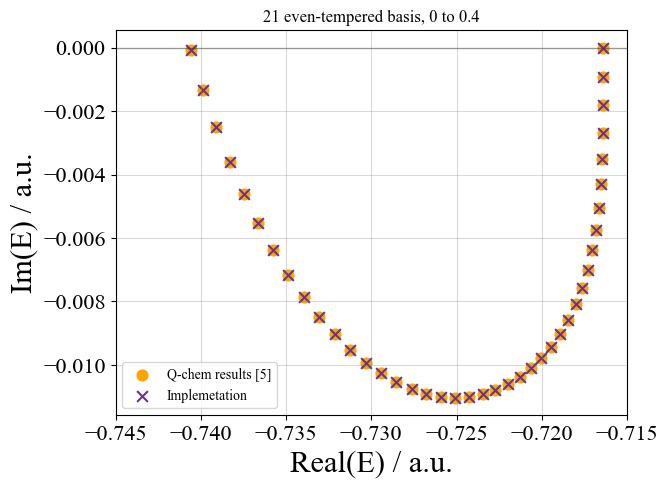

In [51]:
fig, ax = plt.subplots(figsize=(6.6, 5))

ss=60

ax.scatter(E_MP2_even_2s2_qchem.real, E_MP2_even_2s2_qchem.imag, label="Q-chem results [5]", marker="o", c="orange", s=ss)
ax.scatter(
    E_mp2_even_2s2_impl.real,
    E_mp2_even_2s2_impl.imag,
    label="Implemetation",
    c="RebeccaPurple",
    marker="x",
    s=ss
)

ax.axhline(0, color='black', linewidth=1, alpha=0.3)
ax.axvline(0, color='black', linewidth=1, alpha=0.3)

# ax.spines[['top', 'right']].set_visible(False)

ax.set_xlabel('Real(E) / a.u.', fontsize=22)
ax.set_ylabel('Im(E) / a.u.', fontsize=22)
ax.tick_params(axis='both', labelsize=16)

ax.grid(True, which='major', color='gray', linestyle='-', alpha=0.3, zorder=0)

plt.xlim([-.745,-.715])
# plt.ylim([-3, 0.2])

plt.title("21 even-tempered basis, 0 to 0.4")
ax.legend()
plt.show()

In [20]:
error = E_MP2_even_2s2_qchem - E_mp2_even_2s2_impl
print(f"Mean error: {np.mean(error): 6.4E}")
print(f"Max error:  {np.max(error): 6.4E}")

Mean error: -8.3970E-10-5.4295E-10j
Max error:   4.5612E-09-3.8671E-09j


# Test Generation
Instead of testing on the whole trajs we are building tests for particular combinations of basis and angle:
| Configuration | Basis Set | $\theta$ | Energy ($E$) |
| :---   |          :--- | :--- | :--- |
| $1s^2$ |   aug-cc-pvqz | $0.04$ | $-2.89725754 + 8.624 \cdot 10^{-05}i$ |
| $1s^2$ | even-tempered | $0.05$ | $-2.87517703 + 1 \cdot 10^{-08}i$ |
| $2s^2$ |   aug-cc-pvqz | $0.05$ | $-0.73805956 - 0.00201875i$ |
| $2s^2$ | even-tempered | $0.23$ | $-0.7259088 - 0.01099962i$ |

In [21]:
eners = [
    E_MP2_qz_1s2_qchem,
    E_MP2_even_1s2_qchem,
    E_MP2_qz_2s2_qchem, 
    E_MP2_even_2s2_qchem
]

impls = [
    E_mp2_qz_1s2_impl,
    E_mp2_even_1s2_impl,
    E_mp2_qz_2s2_impl,
    E_mp2_even_2s2_impl
]

indices = [4,5,5,23]


for ener, impl, index in zip(eners, impls, indices):
    value = ener[index]
    print(index*0.01, value)
    print(f'.   {value - impl[index]}')

0.04 (-2.89725754+8.624e-05j)
.   (-8.451372934814572e-10+7.146131233146721e-11j)
0.05 (-2.87517703+1e-08j)
.   (4.2120213983309895e-09+2.127233517199778e-09j)
0.05 (-0.73805956-0.00201875j)
.   (1.1600493898811237e-09+2.454483158820936e-09j)
0.23 (-0.7259088-0.01099962j)
.   (4.1437897557727865e-10-3.0290260594895146e-09j)
